# PFAS Passive Membrane Permeation — Descriptor Analysis

This notebook reproduces the descriptor-based analysis end to end:
compute RDKit descriptors for a PFAS panel, examine the chain-length /
lipophilicity trend, compare headgroup families, and inspect descriptor
correlations.

**Research question:** Can classical molecular descriptors explain differences
in passive membrane permeation propensity among PFAS compounds?

> This is an exploratory descriptor screen, not a validated model. See the
> repository README for the full scientific framing and limitations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

## 1. Load the computed descriptors

Descriptors are produced by `src/compute_descriptors.py` (RDKit). Here we load
the resulting table.

In [2]:
df = pd.read_csv("../data/pfas_descriptors.csv")
df[["abbreviation", "class", "n_perfluoro_carbons", "headgroup",
    "mw", "clogp", "tpsa", "fraction_F", "permeation_proxy"]]

,abbreviation,class,n_perfluoro_carbons,headgroup,mw,clogp,tpsa,fraction_F,permeation_proxy
0,PFBA,carboxylic_acid,3,carboxylate,214.04,1.904,37.30,0.538,0.785
1,PFPeA,carboxylic_acid,4,carboxylate,264.04,2.539,37.30,0.562,1.420
2,PFHxA,carboxylic_acid,5,carboxylate,314.05,3.175,37.30,0.579,2.056
3,PFHpA,carboxylic_acid,6,carboxylate,364.06,3.810,37.30,0.591,2.691
4,PFOA,carboxylic_acid,7,carboxylate,414.06,4.445,37.30,0.600,3.326
5,PFNA,carboxylic_acid,8,carboxylate,464.07,5.080,37.30,0.607,3.961
6,PFDA,carboxylic_acid,9,carboxylate,514.08,5.716,37.30,0.613,4.597
7,PFBS,sulfonic_acid,4,sulfonate,300.10,2.300,54.37,0.529,0.669
8,PFHxS,sulfonic_acid,6,sulfonate,400.11,3.571,54.37,0.565,1.940
9,PFOS,sulfonic_acid,8,sulfonate,500.13,4.841,54.37,0.586,3.210


## 2. Chain length vs lipophilicity

We expect lipophilicity (cLogP) to rise monotonically with perfluorinated
chain length. We fit a linear trend on the perfluorocarboxylic acid (PFCA)
homologous series, which is the cleanest comparison.

In [3]:
pfca = df[df["class"] == "carboxylic_acid"]
slope, intercept, r, p, se = stats.linregress(
    pfca["n_perfluoro_carbons"], pfca["clogp"])
print(f"PFCA series: cLogP = {slope:.3f} * nCF + {intercept:.3f}")
print(f"  slope = {slope:.3f} cLogP units per CF2")
print(f"  R^2   = {r**2:.4f}   (n = {len(pfca)}, p = {p:.2e})")

PFCA series: cLogP = 0.635 * nCF + -0.002
  slope = 0.635 cLogP units per CF2
  R^2   = 1.0000   (n = 7, p = 1.95e-19)


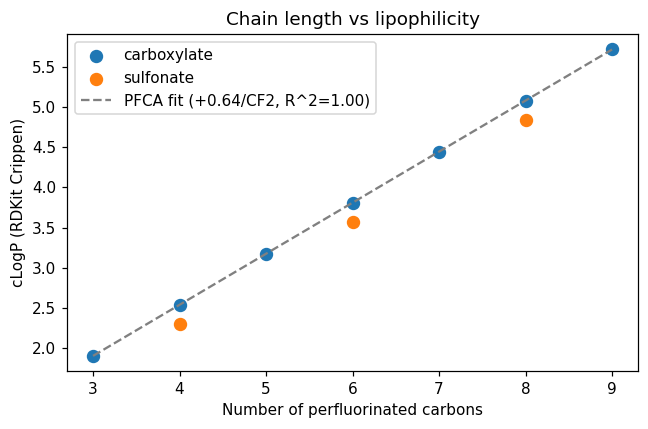

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for hg, sub in df.groupby("headgroup"):
    ax.scatter(sub["n_perfluoro_carbons"], sub["clogp"], s=60, label=hg)
xs = np.array([pfca["n_perfluoro_carbons"].min(), pfca["n_perfluoro_carbons"].max()])
ax.plot(xs, slope*xs + intercept, "--", color="grey",
        label=f"PFCA fit (+{slope:.2f}/CF2, R^2={r**2:.2f})")
ax.set_xlabel("Number of perfluorinated carbons")
ax.set_ylabel("cLogP (RDKit Crippen)")
ax.set_title("Chain length vs lipophilicity")
ax.legend()
plt.tight_layout()
plt.show()

> **Caveat.** The near-perfect linearity partly reflects how RDKit's Crippen
> cLogP is constructed (an additive atom-contribution model) and the known
> unreliability of cLogP for perfluorinated systems. This confirms internal
> consistency rather than independently validating the biophysics.

## 3. Headgroup effect at matched chain length

Comparing carboxylates and sulfonates at the same chain length isolates the
headgroup contribution.

In [5]:
matched = (df[df["n_perfluoro_carbons"].isin(
    df.groupby("n_perfluoro_carbons")["headgroup"].nunique()
      .loc[lambda s: s > 1].index)]
    .sort_values(["n_perfluoro_carbons", "headgroup"]))
matched[["abbreviation", "n_perfluoro_carbons", "headgroup",
         "clogp", "tpsa", "permeation_proxy"]]

,abbreviation,n_perfluoro_carbons,headgroup,clogp,tpsa,permeation_proxy
1,PFPeA,4,carboxylate,2.539,37.30,1.420
7,PFBS,4,sulfonate,2.300,54.37,0.669
3,PFHpA,6,carboxylate,3.810,37.30,2.691
8,PFHxS,6,sulfonate,3.571,54.37,1.940
5,PFNA,8,carboxylate,5.080,37.30,3.961
9,PFOS,8,sulfonate,4.841,54.37,3.210


## 4. Descriptor correlations with the permeation proxy

How much does each descriptor track the heuristic permeation proxy across this
panel?

In [6]:
cols = ["n_perfluoro_carbons", "mw", "clogp", "tpsa",
        "fraction_F", "permeation_proxy"]
corr = df[cols].corr()
print("Correlation of each descriptor with permeation_proxy:")
print(corr["permeation_proxy"].sort_values(ascending=False).round(3))

Correlation of each descriptor with permeation_proxy:
permeation_proxy       1.000
clogp                  0.982
fraction_F             0.964
n_perfluoro_carbons    0.962
mw                     0.900
tpsa                  -0.275
Name: permeation_proxy, dtype: float64


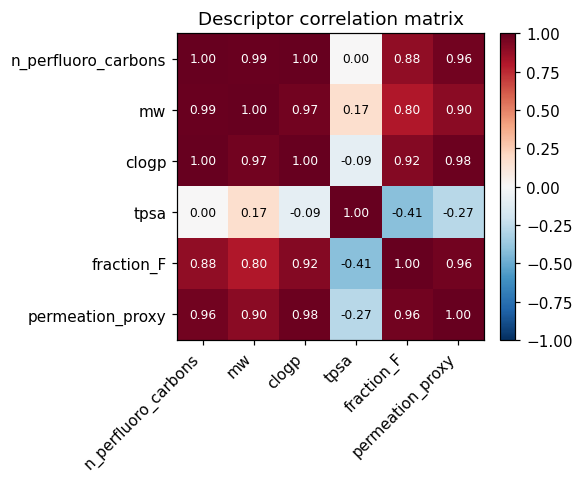

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.values[i,j]) > 0.6 else "black",
                fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Descriptor correlation matrix")
plt.tight_layout()
plt.show()

## 5. Summary

- cLogP rises ~**+0.64 per CF2** across the PFCA series (R^2 approximately 1.0),
  the expected chain-length / lipophilicity trend — but see the cLogP caveat.
- At matched chain length, **carboxylates are slightly more lipophilic** than
  sulfonates, which carry higher TPSA.
- The permeation proxy is dominated by lipophilicity and chain length; TPSA
  varies only between the two headgroup families here.

These descriptor-level trends are intended to **frame hypotheses for molecular
dynamics / PMF validation**, not to predict permeability. See the README for
the full list of limitations and the proposed MD validation plan.